## Neural networks and deep learning

Learn about neural nets and build a model for classifying images of clothes

### Fashion Classification

Dataset:

- Full: https://github.com/alexeygrigorev/clothing-dataset
- Small: https://github.com/alexeygrigorev/clothing-dataset-small

Links:

- https://cs231n.github.io

In [ ]:
# clone the repo
!git clone https://github.com/alexeygrigorev/clothing-dataset-small.git

Cloning into 'clothing-dataset-small'...
Updating files:   4% (182/3783)
Updating files:   5% (190/3783)
Updating files:   6% (227/3783)
Updating files:   7% (265/3783)
Updating files:   8% (303/3783)
Updating files:   9% (341/3783)
Updating files:  10% (379/3783)
Updating files:  10% (393/3783)
Updating files:  11% (417/3783)
Updating files:  12% (454/3783)
Updating files:  13% (492/3783)
Updating files:  14% (530/3783)
Updating files:  14% (549/3783)
Updating files:  15% (568/3783)
Updating files:  16% (606/3783)
Updating files:  17% (644/3783)
Updating files:  17% (652/3783)
Updating files:  18% (681/3783)
Updating files:  19% (719/3783)
Updating files:  20% (757/3783)
Updating files:  20% (766/3783)
Updating files:  20% (787/3783)
Updating files:  21% (795/3783)
Updating files:  21% (796/3783)
Updating files:  21% (828/3783)
Updating files:  22% (833/3783)
Updating files:  22% (843/3783)
Updating files:  23% (871/3783)
Updating files:  23% (888/3783)
Updating files:  24% (908/3783)

## TensorFlow and Keras

- Installing TensorFlow
- Loading Images

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
from tensorflow import keras

In [3]:
from tensorflow.keras.utils import load_img

In [4]:
path = "../06_Deep Learning/clothing-dataset-small/train/t-shirt"
name = "5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg"
full_name = f"{path}/{name}"
img = load_img(full_name, target_size=(299, 299))

## Pre-trained convolutional neural networks

- Imagenet dataset: https://www.image-net.org/
- Pre-trained models: https://keras.io/api/applications/

In [5]:
# import the necessary libraries
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [6]:
# use the pretrained model
model = Xception(weights="imagenet", input_shape=(299, 299, 3))


In [7]:
x = np.array([img])

# use the preprocess input function use by the creators to preprocess the img
X = preprocess_input(x)

# predict the class of the image
pred = model.predict(X)

# use decode predictions to see the class of the image
decode_predictions(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


[[('n03595614', 'jersey', np.float32(0.679244)),
  ('n02916936', 'bulletproof_vest', np.float32(0.039600383)),
  ('n04370456', 'sweatshirt', np.float32(0.03529966)),
  ('n03710637', 'maillot', np.float32(0.010884161)),
  ('n04525038', 'velvet', np.float32(0.0018057661))]]

*The actual class of the image is a shirt, but shirt as a class is not seen in image net, so the pretrained model would be adjusted to be an ideal model for our task of classifying the image*

## Convolutional Neural Network

- Types of layers
- Convolutional Layers and filters
- Dense layers

There are more layers. Read here: https://cs231n.github.io/

## Transfer learning

- Reading data with ImageDataGenerator
- Train Xception on smaller images (150 x 150)

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(150,150),
    batch_size=32
)

Found 3068 images belonging to 10 classes.


In [10]:
## check the classes in the train dataset
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [11]:
X, y = next(train_ds)

In [12]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(150,150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


In [13]:
base_model = Xception(weights="imagenet", 
                      include_top=False, 
                      input_shape=(150, 150, 3))

# freeze convolutional layers
base_model.trainable=False

inputs = keras.Input(shape = (150, 150, 3))

base = base_model(inputs, training = False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

In [14]:
learning_rate = 0.01

optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
loss = keras.losses.CategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['accuracy']
)

In [15]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.6747 - loss: 1.2883 - val_accuracy: 0.7625 - val_loss: 0.9558
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8181 - loss: 0.6169 - val_accuracy: 0.7771 - val_loss: 1.0470
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.8748 - loss: 0.3980 - val_accuracy: 0.7947 - val_loss: 0.8294
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.9237 - loss: 0.2102 - val_accuracy: 0.7713 - val_loss: 1.0818
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9374 - loss: 0.1747 - val_accuracy: 0.7830 - val_loss: 1.0781
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9550 - loss: 0.1325 - val_accuracy: 0.7771 - val_loss: 1.0483
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.9713 - loss: 0.0849 - val_accuracy: 0.8270 - val_loss: 0.8612
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9857 - loss: 0.0553 - val_accuracy: 0.8299 - v

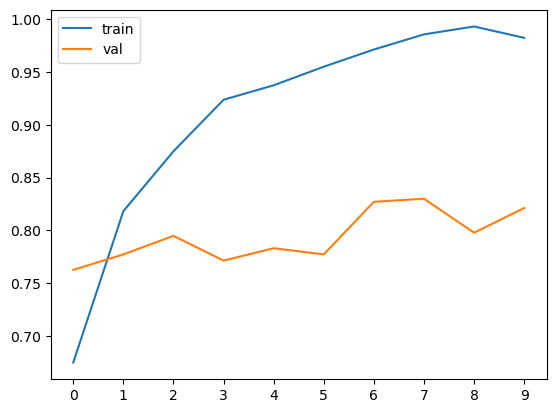

In [16]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xticks(np.arange(10))
plt.legend()
plt.show()

## Adjusting the learning rate

- What's the learning rate
- Trying different values

In [17]:
def make_model(learning_rate):
    base_model = Xception(weights="imagenet", 
                      include_top=False, 
                      input_shape=(150, 150, 3))

    # freeze convolutional layers
    base_model.trainable=False

    ##############################################

    inputs = keras.Input(shape = (150, 150, 3))

    base = base_model(inputs, training = False)

    vectors = keras.layers.GlobalAveragePooling2D()(base)

    outputs = keras.layers.Dense(10)(vectors)

    model = keras.Model(inputs, outputs)

    ##############################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [18]:
scores = {}
for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(lr)

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history

    print()
    print()

0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.3631 - loss: 1.9437 - val_accuracy: 0.4897 - val_loss: 1.6187
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.5508 - loss: 1.4052 - val_accuracy: 0.5924 - val_loss: 1.2547
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.6196 - loss: 1.1558 - val_accuracy: 0.6891 - val_loss: 1.0686
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.6666 - loss: 1.0094 - val_accuracy: 0.7331 - val_loss: 0.9470
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.7044 - loss: 0.9156 - val_accuracy: 0.7537 - val_loss: 0.8754
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.7229 - loss: 0.8454 - val_accuracy: 0.7947 - val_loss: 0.8161
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.7415 - loss: 0.7930 - val_accuracy: 0.7859 - val_loss: 0.7807
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.7581 - loss: 0.7506 - val_accuracy: 0.7

*Plot the validation accuracy of the different learning rates*

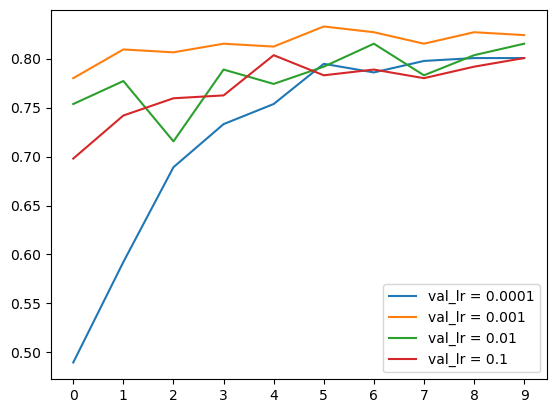

In [21]:
for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f'val_lr = {lr}')
plt.xticks(np.arange(10))
plt.legend()
plt.show()

*remove the learning rates with the worst performances*

In [27]:
del scores[0.0001]
del scores[0.1]

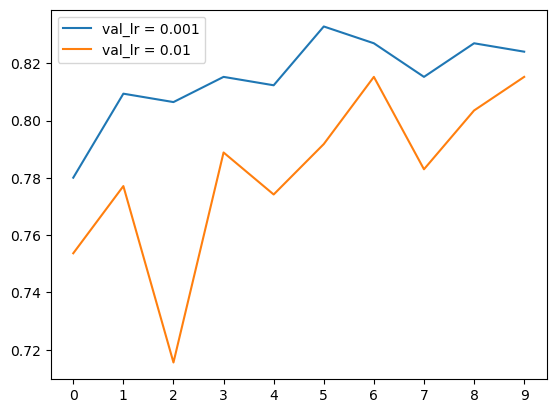

In [28]:
for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f'val_lr = {lr}')
plt.xticks(np.arange(10))
plt.legend()
plt.show()

*we will go with the learning rate of 0.001 since it is the best learning rate with the best validation scores*